# 📘 Tutorial: Working with the HealthDataModule and Adding New Modalities

Welcome to the team! This notebook serves as an interactive starter guide and tutorial on how to use the project's data processing pipeline and extend it to new sensor modalities (e.g., `proximity` / Bluetooth device counts, `heart_rate`, etc.).

By following this guide, you will learn:
1. The **Data Contract** required for new modalities.
2. How to write **custom preprocessors** (e.g., to handle column renames for table-specific schemas like `proximity`).
3. How the `HealthDataModule` setup life-cycle works.
4. How to inspect and verify the resulting PyTorch tensors for modeling.

## 🛠️ Step 1: Environment Setup & Common Imports

We begin by importing standard libraries, setting up the python paths using `rootutils` so that `src` imports resolve correctly, and loading environment variables.

In [1]:
import os
import sys
import rootutils
import pandas as pd
import numpy as np

# Setup the project root indicator
root = rootutils.setup_root(search_from=os.getcwd(), indicator=".project-root", pythonpath=True)
print(f"Project root located at: {root}")

Project root located at: /Users/khickey/Desktop/lemurs/lemurs-modeling


## 📡 Step 2: The Raw Data Contract

For the database service and `CohortBuilder` to process a data stream, the cleaned DataFrame must adhere to a simple schema contract:
1. **`app_user_id`** (Integer): Maps the sensor reading to a user.
2. **`start_timestamp`** (Timestamp/Datetime): The start time of the sensor recording.
3. **Value Column** (e.g., `steps` for steps, `number_of_devices` for proximity): The actual numeric metric.

Let's look at the raw schema of the `proximity` table to see why it needs a preprocessor to satisfy this contract.

In [2]:
from src.utils.database_service import DatabaseService
from dotenv import load_dotenv

# Load environment variables (.env)
load_dotenv()

# Initialize and connect
db = DatabaseService()
if db.connect():
    print("Successfully connected to the database!")
    # Extract a small sample from the proximity table
    proximity_df = db.extract_from_database("proximity")
    print(f"Proximity dataframe shape: {proximity_df.shape}")
    print("\nFirst few rows of raw Proximity (Bluetooth scan) data:")
    display(proximity_df.head())
    db.disconnect()
else:
    print("Database connection failed. Check your .env file.")

Successfully connected to the database!


/Users/khickey/Desktop/lemurs/lemurs-modeling/src/utils/database_service.py:93: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, self.connection)


Proximity dataframe shape: (15905, 4)

First few rows of raw Proximity (Bluetooth scan) data:


,id,app_user_id,number_of_devices,timestamp
0,1,2,38,2025-11-06 15:45:22.193
1,2,2,38,2025-11-06 15:45:22.193
2,3,5,48,2025-11-14 16:39:43.013
3,4,5,48,2025-11-14 16:39:43.013
4,5,5,36,2025-11-15 10:15:19.344


## 🧹 Step 3: Modality Preprocessing (Renaming to match the contract)

Notice that the `proximity` table has a `timestamp` column instead of `start_timestamp`. Since the `CohortBuilder` looks for `start_timestamp` to align the sensor logs with surveys, running it directly on `proximity` would cause a `KeyError`.

This is exactly what the **preprocessing stage** is for! We will write a custom preprocessor function for `proximity` to rename `timestamp` to `start_timestamp` and optionally clean up outliers or drop duplicates.

In [ ]:
def preprocess_proximity(df: pd.DataFrame) -> pd.DataFrame:
    """Preprocesses raw Proximity (Bluetooth Scan) data.
    
    Args:
        df: Raw DataFrame from proximity table.
    Returns:
        Cleaned DataFrame satisfying the DataModule contract.
    """
    # 1. Rename 'timestamp' to 'start_timestamp' to satisfy the DataModule contract
    df = df.rename(columns={"timestamp": "start_timestamp"})
    
    # 2. Filter out invalid/negative device counts
    df = df[df["number_of_devices"] >= 0].copy()

    # 3. DO ANY OTHER DATA PROCESSING/CLEANING STEPS HERE (REMOVE DUPLICATES, IMPUTE VALUES, ETC)
    
    return df

# Verify the preprocessor locally
db.connect()
raw_df = db.extract_from_database("proximity")
db.disconnect()

cleaned_df = preprocess_proximity(raw_df)
print("Columns after preprocessing:", list(cleaned_df.columns))
display(cleaned_df.head())

/Users/khickey/Desktop/lemurs/lemurs-modeling/src/utils/database_service.py:93: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, self.connection)


Columns after preprocessing: ['id', 'app_user_id', 'number_of_devices', 'start_timestamp']


,id,app_user_id,number_of_devices,start_timestamp
0,1,2,38,2025-11-06 15:45:22.193
1,2,2,38,2025-11-06 15:45:22.193
2,3,5,48,2025-11-14 16:39:43.013
3,4,5,48,2025-11-14 16:39:43.013
4,5,5,36,2025-11-15 10:15:19.344


## 🏗️ Step 4: Initializing Datamodule Components

The datamodule relies on component classes to handle specific tasks:
1. **`LabelAggregator`**: Aggregates survey answers into modeling labels.
2. **`TimeSampler`**: Samples and resamples temporal data preceding survey responses.
3. **`Scaler`**: Standardizes feature sequences.

In [4]:
from src.data.components.label_aggregators import MeanAggregator
from src.data.components.samplers import RollingSampler
from sklearn.preprocessing import StandardScaler

# Aggregator: averages survey answers for questions 2 and 3, and binarizes with a threshold of 2.0
aggregator = MeanAggregator(question_ids=[2, 3], threshold=2.0)

# Sampler: 24-hour lookback window with hourly resampling
sampler = RollingSampler(lookback_hours=24.0, resample_freq="1h")

# Scaler: standard scaler
scaler = StandardScaler()

## 🚀 Step 5: Running the DataModule Pipeline

Now, we initialize the `HealthDataModule` including our new `proximity` modality, register the column mappings and our custom preprocessor, and run `setup()`.

In [5]:
from src.data.health_datamodule import HealthDataModule

# Register modalities, columns, and preprocessors
# Note: 'proximity' is mapped to database column 'number_of_devices'
modalities = ["step", "proximity"]
modality_cols = {"step": "steps", "proximity": "number_of_devices"}
preprocessors = {"proximity": preprocess_proximity}

datamodule = HealthDataModule(
    aggregator=aggregator,
    sampler=sampler,
    scaler=scaler,
    preprocessors=preprocessors,
    modalities=modalities,
    batch_size=8,
    split_mode="user",               # Disjoint populations (no user leakage between splits)
    train_val_test_split=(0.7, 0.15, 0.15),
    random_state=42
)

# Trigger setup to fetch, preprocess, split, and scale data
datamodule.setup()

print("✅ DataModule setup completed successfully!")
print(f"Train samples: {len(datamodule.data_train)}")
print(f"Val samples:   {len(datamodule.data_val)}")
print(f"Test samples:  {len(datamodule.data_test)}")

/Users/khickey/Desktop/lemurs/lemurs-modeling/src/utils/database_service.py:93: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, self.connection)


/Users/khickey/Desktop/lemurs/lemurs-modeling/src/utils/database_service.py:93: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, self.connection)


/Users/khickey/Desktop/lemurs/lemurs-modeling/src/utils/database_service.py:93: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, self.connection)


Filtering out 80 duplicate survey responses submitted within 10 minutes with identical answers.


/Users/khickey/Desktop/lemurs/lemurs-modeling/src/utils/database_service.py:93: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, self.connection)
Collapsed 2044 survey responses into 1081 unique daily samples per user.


✅ DataModule setup completed successfully!
Train samples: 725
Val samples:   156
Test samples:  193


## 🔍 Step 6: Inspecting Resulting PyTorch Tensors

Let's fetch a single batch from the training loader and inspect the structure of the tensors that our model will receive.

In [6]:
train_loader = datamodule.train_dataloader()
batch = next(iter(train_loader))

# Unpack the batch
# HealthDataset yields: (Features, Labels, UserIndices)
x, y, user_idx = batch

print(f"Features shape (x): {x.shape} -> [Batch Size, Sequence Length (24 hrs), Modalities (Step, Proximity)]")
print(f"Labels shape (y):   {y.shape} -> [Batch Size]")
print(f"User Indices (user_idx): {user_idx.shape} -> [Batch Size]")

print("\nFirst sample features in batch (first 3 hours):")
print(x[0, :3, :].numpy())

Features shape (x): torch.Size([8, 24, 2]) -> [Batch Size, Sequence Length (24 hrs), Modalities (Step, Proximity)]
Labels shape (y):   torch.Size([8]) -> [Batch Size]
User Indices (user_idx): torch.Size([8]) -> [Batch Size]

First sample features in batch (first 3 hours):
[[-0.15883635 -0.23211738]
 [-0.15883635 -0.23211738]
 [-0.15883635 -0.23211738]]


## 📉 Step 7: Visualizing Feature Sequences

Let's plot the resampled and scaled sequences for a sample in the batch to verify they look correct.

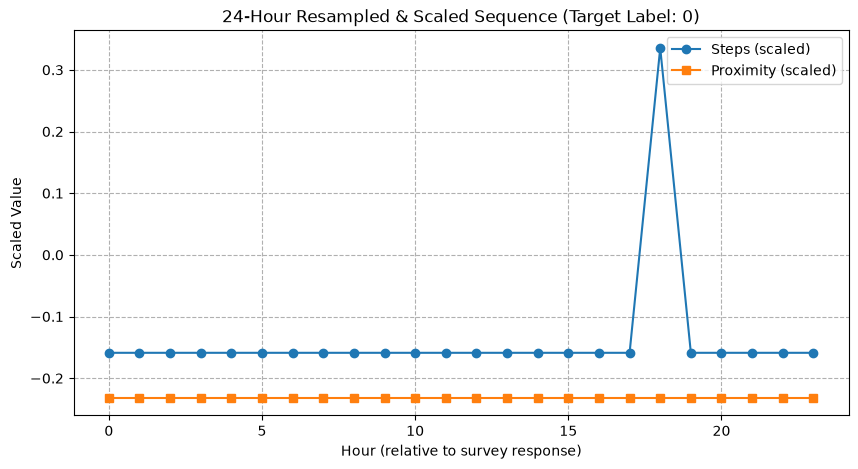

In [7]:
import matplotlib.pyplot as plt

sample_idx = 0
sequence = x[sample_idx].numpy()
label = y[sample_idx].item()

plt.figure(figsize=(10, 5))
plt.plot(sequence[:, 0], label="Steps (scaled)", marker='o')
plt.plot(sequence[:, 1], label="Proximity (scaled)", marker='s')
plt.title(f"24-Hour Resampled & Scaled Sequence (Target Label: {label})")
plt.xlabel("Hour (relative to survey response)")
plt.ylabel("Scaled Value")
plt.legend()
plt.grid(True, linestyle="--")
plt.show()

## 🤖 Step 8: Building and Testing a Simple Model

Finally, let's pass our batched data through a simple LSTM model incorporating subject-specific user embeddings.

In [8]:
import torch
import torch.nn as nn

class HealthLSTM(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, num_users: int, embedding_dim: int):
        super().__init__()
        # User embedding layer to model subject-level baseline variation
        self.user_embedding = nn.Embedding(num_embeddings=num_users, embedding_dim=embedding_dim)
        
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim + embedding_dim, 1)
        
    def forward(self, x, user_idx):
        # LSTM output
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        
        # User embeddings
        user_emb = self.user_embedding(user_idx)
        
        # Concatenate temporal and subject-specific static features
        combined = torch.cat([last_hidden, user_emb], dim=-1)
        return self.fc(combined).squeeze(-1)

# Setup parameters
num_users = len(datamodule.user_to_idx) + 1  # +1 for unseen users (index 0)
model = HealthLSTM(input_dim=2, hidden_dim=16, num_users=num_users, embedding_dim=8)

# Forward pass
predictions = model(x, user_idx)
print(f"Forward pass successful! Output logits shape: {predictions.shape}")
print("Predictions:", predictions.detach().numpy())

Forward pass successful! Output logits shape: torch.Size([8])
Predictions: [-0.2474923  -0.02900544 -0.23278771 -0.02900544  0.20771831  0.19979838
  0.14639173 -0.41258755]
